# Notebook 2: Feature Engineering, Model Training, and Evaluation
## US Census Income Dataset -- Predicting Who Earns Over $50K

**Pipeline stages:**
1. Feature engineering (informed by EDA findings)
2. Preprocessing pipeline (sklearn)
3. Competing model comparison (Logistic Regression, Random Forest, LightGBM)
4. LightGBM hyperparameter tuning (Optuna)
5. Final evaluation on held-out test set
6. Model interpretability (SHAP)

**Design philosophy:** Production-ready, reproducible pipeline. All transformations fit on train only and applied to test. No target leakage.

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import optuna
import shap

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
)
from lightgbm import LGBMClassifier

from src.utils import (
    COLUMN_NAMES, CONTINUOUS_COLS, TARGET_COL, INSTANCE_WEIGHT_COL,
    EDUCATION_ORDER, INCOME_PALETTE, INCOME_LABELS, TARGET_MAP,
    TRAIN_PATH, TEST_PATH, FIGURES_DIR, MODELS_DIR, PROCESSED_DIR,
    COLS_TO_DROP, HIGH_CARDINALITY_COLS, LOW_CARDINALITY_COLS,
    DOCS_DIR, FIGURE_DPI, RANDOM_STATE,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': FIGURE_DPI, 'figure.figsize': (12, 5)})
for d in [FIGURES_DIR, MODELS_DIR, PROCESSED_DIR, DOCS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def savefig(name: str):
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=FIGURE_DPI)
    plt.show()

## 1. Data Loading

In [2]:
def load_census(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path, header=None, names=COLUMN_NAMES,
        na_values=['?', ' ?'], skipinitialspace=True,
    )
    str_cols = df.select_dtypes(include=['object']).columns
    df[str_cols] = df[str_cols].apply(lambda s: s.str.strip().str.rstrip('.'))
    df[TARGET_COL] = df[TARGET_COL].map(TARGET_MAP)
    return df

train_raw = load_census(TRAIN_PATH)
test_raw  = load_census(TEST_PATH)
print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')

Train: (199523, 42)  |  Test: (99762, 42)


## 2. Feature Engineering

Decisions informed by EDA:
- **Capital income flag:** Capital gains/dividends are zero for 96%+ of records but highly predictive. A binary flag captures membership in the high-income capital-owning group without being dominated by raw magnitude outliers.
- **Education ordinal:** Education has a clear monotonic relationship with income -- ordinal encoding preserves this ordering signal for linear models and helps gradient boosting as well.
- **Consolidated birth country:** Father/mother country of birth carry overlapping signal; `any_foreign_born` summarizes nativity without redundancy.
- **Drop detailed codes:** `detailed_industry_recode` and `detailed_occupation_recode` are finer-grained recodes of the major versions. Retaining both introduces redundancy and increases dimensionality without proportional gain.

In [3]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- Derived binary flags ---
    df['has_capital_income'] = (
        (df['capital_gains'] > 0) | (df['dividends_from_stocks'] > 0)
    ).astype(int)

    df['capital_income_total'] = df['capital_gains'] + df['dividends_from_stocks']

    df['zero_wage'] = (df['wage_per_hour'] == 0).astype(int)

    # Any foreign-born parent consolidates 3 birth-country columns to a compact signal
    us_values = ['United-States', 'Outlying-U S (Guam USVI etc)']
    df['any_foreign_born_parent'] = (
        (~df['birth_country_father'].isin(us_values)) |
        (~df['birth_country_mother'].isin(us_values))
    ).astype(int)

    # Age bucketed for potential interaction with LightGBM leaf splits
    df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 17, 24, 34, 44, 54, 64, 120],
        labels=['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
    ).astype(str)

    # Drop redundant columns
    df = df.drop(columns=COLS_TO_DROP, errors='ignore')

    return df

train = engineer_features(train_raw)
test  = engineer_features(test_raw)

print(f'After feature engineering: {train.shape[1]} columns')
print('New columns added:', [c for c in train.columns if c not in train_raw.columns])

After feature engineering: 44 columns
New columns added: ['has_capital_income', 'capital_income_total', 'zero_wage', 'any_foreign_born_parent', 'age_group']


## 3. Preprocessing Pipeline

**Column transformer strategy:**
- **Continuous:** passed as-is to LightGBM (handles NaN natively); StandardScaler applied for logistic regression
- **Education (ordinal):** `OrdinalEncoder` using the known education level ordering
- **High-cardinality categoricals (>10 unique):** `TargetEncoder` with cross-fold smoothing -- encodes categories as their smoothed probability of the positive class, avoiding one-hot explosion
- **Low-cardinality categoricals:** `OneHotEncoder` with `handle_unknown='ignore'` for robustness
- **Missing values:** NaN in categoricals is treated as `'Missing'` category (structural non-movers + genuinely unknown); LightGBM handles NaN in numerics natively

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Identify columns actually present after feature engineering
all_feature_cols = [c for c in train.columns if c not in [TARGET_COL, INSTANCE_WEIGHT_COL]]

# Recalculate column sets based on what's present
present_high_card = [c for c in HIGH_CARDINALITY_COLS if c in all_feature_cols]
present_low_card  = [c for c in LOW_CARDINALITY_COLS + ['age_group'] if c in all_feature_cols]
present_continuous = [c for c in all_feature_cols
                      if c not in present_high_card + present_low_card + ['education']]

print(f'Continuous features   : {len(present_continuous)}')
print(f'Education (ordinal)   : 1')
print(f'High-cardinality cats : {len(present_high_card)}')
print(f'Low-cardinality cats  : {len(present_low_card)}')

edu_cats = EDUCATION_ORDER + ['Children']  # Children appear in data

Continuous features   : 11
Education (ordinal)   : 1
High-cardinality cats : 7
Low-cardinality cats  : 25


In [5]:
def build_preprocessor(use_scaling: bool = False) -> ColumnTransformer:
    """
    Build a ColumnTransformer for the census dataset.
    use_scaling=True for Logistic Regression; False for tree-based models.
    """
    transformers = [
        ('education_ordinal',
         OrdinalEncoder(
             categories=[edu_cats],
             handle_unknown='use_encoded_value',
             unknown_value=-1,
         ),
         ['education']
        ),
        ('high_card_target',
         TargetEncoder(smooth='auto', target_type='binary'),
         present_high_card
        ),
        ('low_card_ohe',
         OneHotEncoder(
             handle_unknown='ignore',
             sparse_output=False,
             dtype=np.float32,
         ),
         present_low_card
        ),
    ]

    if use_scaling:
        transformers.append(
            ('continuous_scaled',
             Pipeline([
                 ('impute', SimpleImputer(strategy='median')),
                 ('scale', StandardScaler()),
             ]),
             present_continuous
            )
        )
    else:
        # LightGBM and RF handle NaN natively -- passthrough
        transformers.append(('continuous_passthrough', 'passthrough', present_continuous))

    return ColumnTransformer(transformers=transformers, remainder='drop', verbose_feature_names_out=False)

# Separate features / target / weights
# instance_weight is dropped by engineer_features -- pull it from the raw frame
X_train = train[all_feature_cols]
y_train = train[TARGET_COL]
w_train = train_raw[INSTANCE_WEIGHT_COL]

X_test  = test[all_feature_cols]
y_test  = test[TARGET_COL]

# Imbalance ratio for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'Class ratio (neg/pos): {scale_pos_weight:.2f}')
print(f'Total features: {X_train.shape[1]}')

Class ratio (neg/pos): 15.11
Total features: 43


## 4. Baseline and Competing Models

Three models are evaluated to contextualize LightGBM performance:
1. **Logistic Regression** -- linear baseline, fast, interpretable, shows what a simple model achieves
2. **Random Forest** -- non-linear ensemble, shows gain from tree structures without boosting
3. **LightGBM** -- gradient boosted trees, handles categorical data, sparsity, and imbalance natively

5-fold stratified cross-validation on train set. Primary metric: ROC-AUC.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models_config = {
    'Logistic Regression': Pipeline([
        ('prep', build_preprocessor(use_scaling=True)),
        ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000,
            solver='lbfgs', C=0.1, random_state=RANDOM_STATE
        )),
    ]),
    'Random Forest': Pipeline([
        ('prep', build_preprocessor(use_scaling=False)),
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=12,
            class_weight='balanced_subsample',
            n_jobs=-1, random_state=RANDOM_STATE
        )),
    ]),
    'LightGBM (default)': Pipeline([
        ('prep', build_preprocessor(use_scaling=False)),
        ('clf', LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            num_leaves=63, scale_pos_weight=scale_pos_weight,
            n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
        )),
    ]),
}

cv_results = {}
for name, pipeline in models_config.items():
    print(f'Cross-validating: {name} ...')
    scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='roc_auc', cv=cv, n_jobs=-1
    )
    cv_results[name] = scores
    print(f'  ROC-AUC: {scores.mean():.4f} +/- {scores.std():.4f}')

print('\nCross-validation complete.')

Cross-validating: Logistic Regression ...
  ROC-AUC: 0.9439 +/- 0.0010
Cross-validating: Random Forest ...
  ROC-AUC: 0.9415 +/- 0.0021
Cross-validating: LightGBM (default) ...
  ROC-AUC: 0.9514 +/- 0.0016

Cross-validation complete.


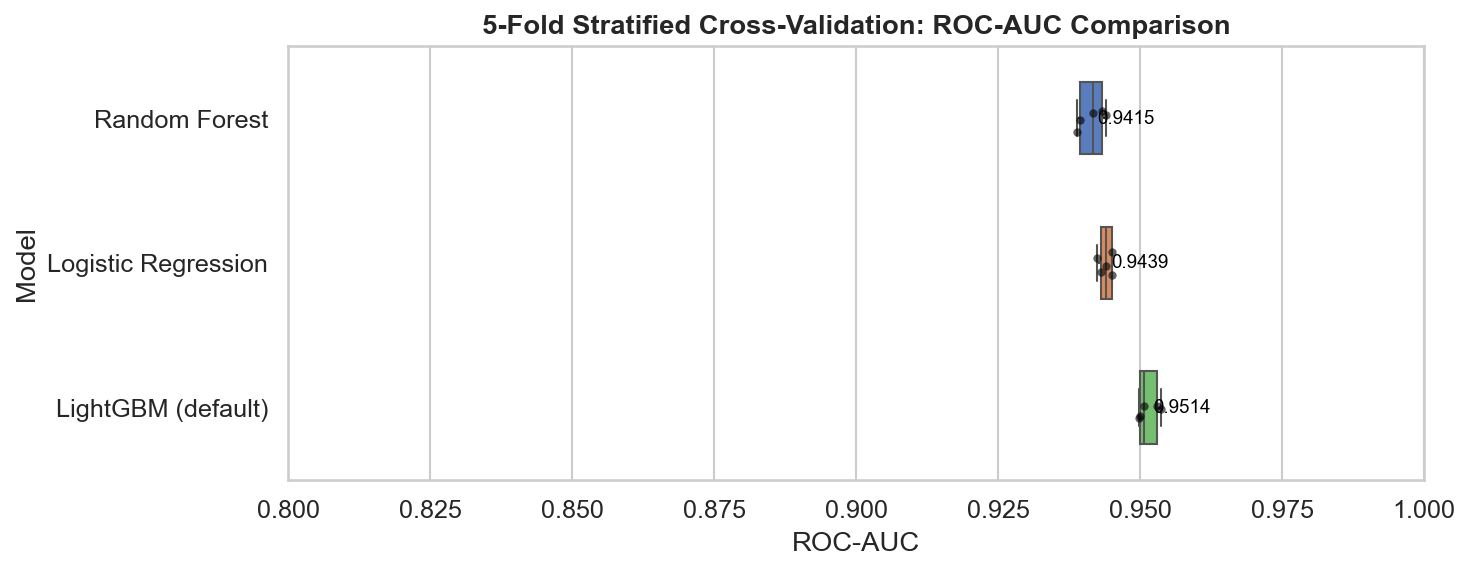

In [7]:
# Visualize CV results
cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(10, 4))
cv_melted = cv_df.melt(var_name='Model', value_name='ROC-AUC')
order = cv_df.mean().sort_values().index.tolist()
sns.boxplot(data=cv_melted, y='Model', x='ROC-AUC', order=order,
            palette='muted', ax=ax, width=0.5)
sns.stripplot(data=cv_melted, y='Model', x='ROC-AUC', order=order,
              color='black', alpha=0.6, size=4, ax=ax)
ax.set_title('5-Fold Stratified Cross-Validation: ROC-AUC Comparison', fontweight='bold')
ax.set_xlim(0.8, 1.0)
for i, model in enumerate(order):
    m = cv_df[model].mean()
    ax.text(m + 0.001, i, f'{m:.4f}', va='center', fontsize=9, color='black')
plt.tight_layout()
savefig('17_cv_comparison')

## 5. LightGBM Hyperparameter Tuning (Optuna)

We run a 60-trial Bayesian optimization search over the key LightGBM hyperparameters. This is done with 3-fold CV (faster than 5-fold) to explore the space efficiently. The best parameters are then retrained on the full training set.

In [8]:
# Fit preprocessor once to avoid repeated refitting during tuning
prep = build_preprocessor(use_scaling=False)
X_train_prep = prep.fit_transform(X_train, y_train)
feature_names_out = prep.get_feature_names_out()
print(f'Preprocessed feature matrix: {X_train_prep.shape}')

X_test_prep = prep.transform(X_test)

Preprocessed feature matrix: (199523, 174)


In [9]:
def objective(trial: optuna.Trial) -> float:
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'n_jobs': -1,
        'random_state': RANDOM_STATE,
        'verbose': -1,
    }
    model = LGBMClassifier(**params)
    cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_prep, y_train, cv=cv_inner, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=60, show_progress_bar=True)

best_params = study.best_params
best_params.update({'scale_pos_weight': scale_pos_weight, 'n_jobs': -1,
                    'random_state': RANDOM_STATE, 'verbose': -1})

print(f'\nBest ROC-AUC (3-fold): {study.best_value:.4f}')
print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Best trial: 47. Best value: 0.953244: 100%|██████████| 60/60 [1:04:17<00:00, 64.30s/it] 


Best ROC-AUC (3-fold): 0.9532
Best hyperparameters:
  n_estimators: 700
  learning_rate: 0.022805507813402185
  num_leaves: 36
  max_depth: 7
  min_child_samples: 54
  subsample: 0.9755759431383653
  colsample_bytree: 0.5886470663397413
  reg_alpha: 1.9999060970731486e-06
  reg_lambda: 8.791668693314812e-07
  scale_pos_weight: 15.113955742206429
  n_jobs: -1
  random_state: 42
  verbose: -1


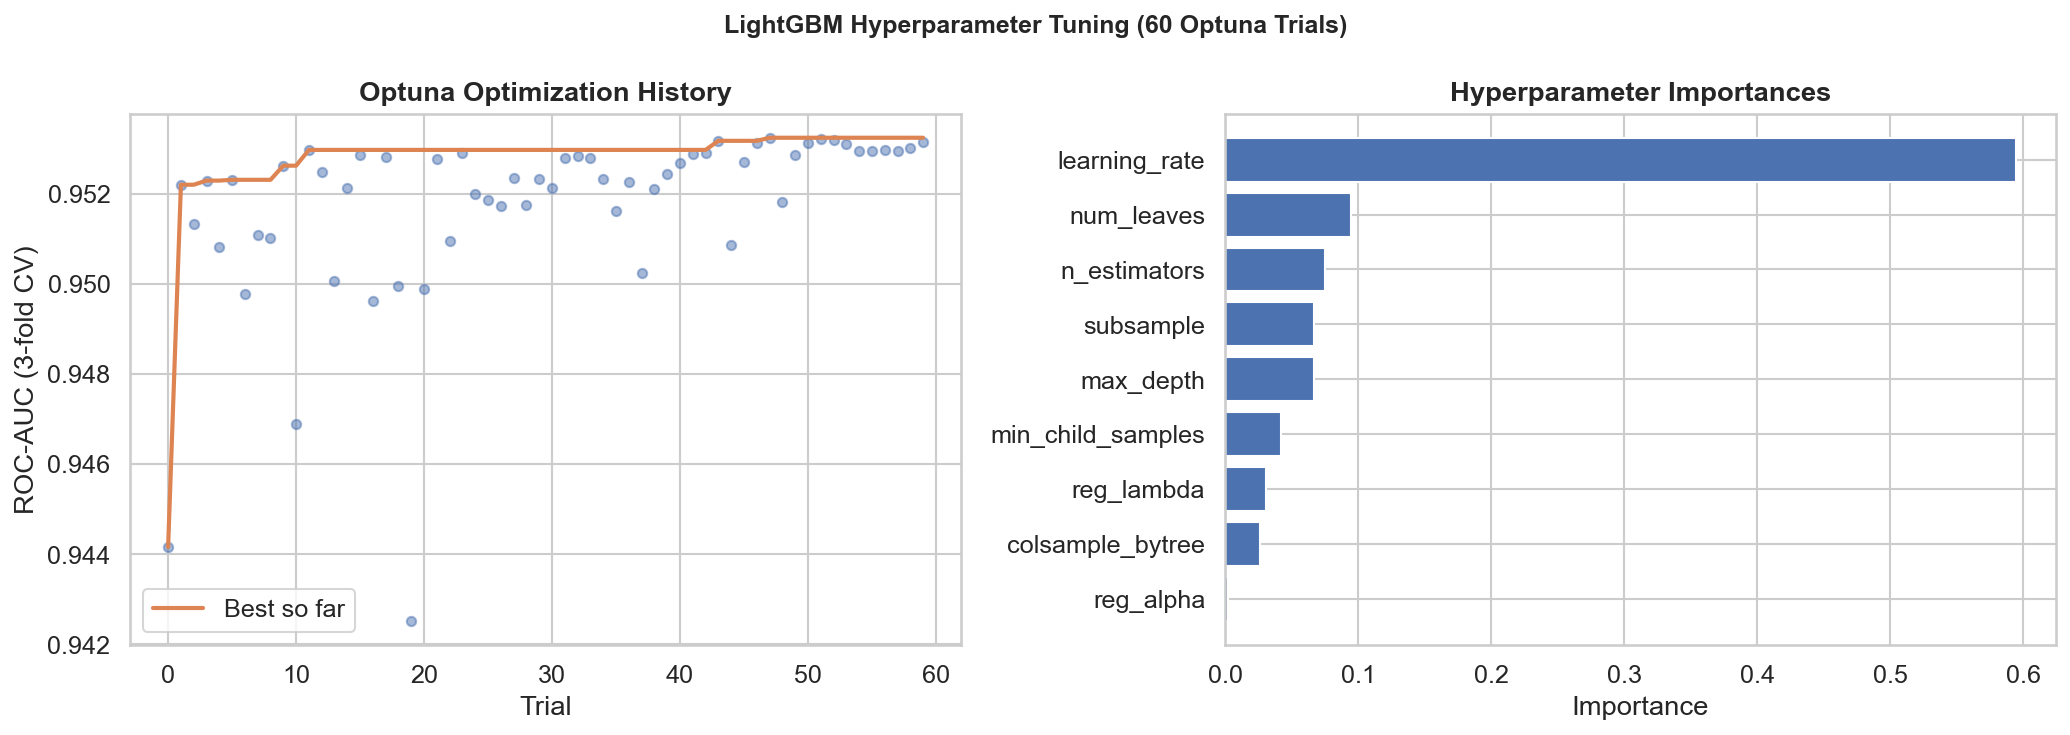

In [10]:
# Optuna optimization history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trials_df = study.trials_dataframe()
ax1.scatter(trials_df['number'], trials_df['value'], alpha=0.5, s=20, color='#4C72B0')
best_so_far = trials_df['value'].cummax()
ax1.plot(trials_df['number'], best_so_far, color='#DD8452', linewidth=2, label='Best so far')
ax1.set_xlabel('Trial')
ax1.set_ylabel('ROC-AUC (3-fold CV)')
ax1.set_title('Optuna Optimization History', fontweight='bold')
ax1.legend()

# Parameter importances
try:
    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame(list(importances.items()), columns=['param', 'importance'])
    imp_df = imp_df.sort_values('importance')
    ax2.barh(imp_df['param'], imp_df['importance'], color='#4C72B0')
    ax2.set_xlabel('Importance')
    ax2.set_title('Hyperparameter Importances', fontweight='bold')
except Exception:
    ax2.text(0.5, 0.5, 'Importance calculation not available', ha='center', va='center')

plt.suptitle('LightGBM Hyperparameter Tuning (60 Optuna Trials)', fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('18_optuna_tuning')

## 6. Train Final Models and Evaluate on Test Set

Models are trained on the full training set and evaluated **once** on the held-out test set. This is the definitive performance comparison.

In [11]:
# Train all final models
final_models = {
    'Logistic Regression': Pipeline([
        ('prep', build_preprocessor(use_scaling=True)),
        ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000,
            solver='lbfgs', C=0.1, random_state=RANDOM_STATE
        )),
    ]),
    'Random Forest': Pipeline([
        ('prep', build_preprocessor(use_scaling=False)),
        ('clf', RandomForestClassifier(
            n_estimators=300, max_depth=15,
            class_weight='balanced_subsample',
            n_jobs=-1, random_state=RANDOM_STATE
        )),
    ]),
    'LightGBM (tuned)': Pipeline([
        ('prep', build_preprocessor(use_scaling=False)),
        ('clf', LGBMClassifier(**best_params)),
    ]),
}

test_results = {}
for name, pipeline in final_models.items():
    print(f'Training: {name} ...')
    pipeline.fit(X_train, y_train)
    proba = pipeline.predict_proba(X_test)[:, 1]
    pred  = pipeline.predict(X_test)
    test_results[name] = {
        'pipeline': pipeline,
        'proba': proba,
        'pred': pred,
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba),
        'f1': f1_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
    }
    print(f'  ROC-AUC: {test_results[name]["roc_auc"]:.4f}')
    print(f'  PR-AUC:  {test_results[name]["pr_auc"]:.4f}')

Training: Logistic Regression ...
  ROC-AUC: 0.9456
  PR-AUC:  0.6067
Training: Random Forest ...
  ROC-AUC: 0.9445
  PR-AUC:  0.5967
Training: LightGBM (tuned) ...
  ROC-AUC: 0.9554
  PR-AUC:  0.6805


In [12]:
# Results summary table
results_table = pd.DataFrame({
    name: {
        'ROC-AUC': r['roc_auc'],
        'PR-AUC': r['pr_auc'],
        'F1 (0.5 thresh)': r['f1'],
        'Precision': r['precision'],
        'Recall': r['recall'],
    }
    for name, r in test_results.items()
}).T.round(4)
print('Test Set Performance:')
display(results_table)

Test Set Performance:


,ROC-AUC,PR-AUC,F1 (0.5 thresh),Precision,Recall
Logistic Regression,0.9456,0.6067,0.4328,0.2851,0.8978
Random Forest,0.9445,0.5967,0.4663,0.3216,0.8477
LightGBM (tuned),0.9554,0.6805,0.4711,0.3193,0.8980


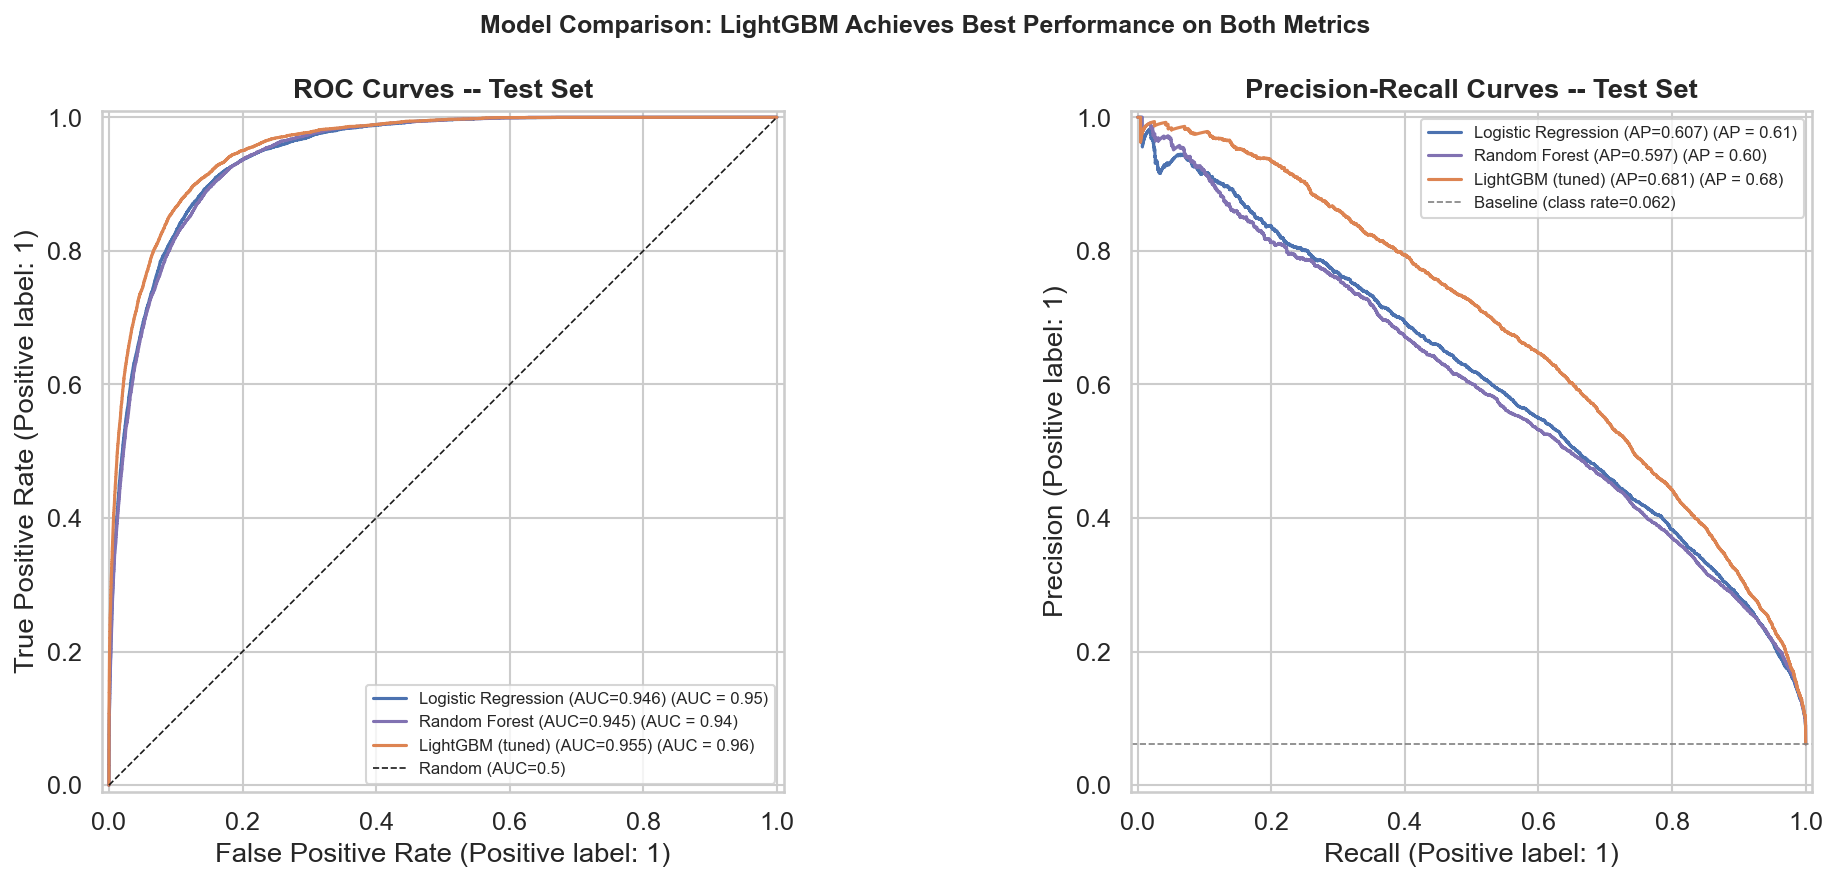

In [13]:
# ROC and PR curves for all models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#4C72B0', '#8172B2', '#DD8452']
for (name, r), color in zip(test_results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, r['proba'], ax=ax1, name=f"{name} (AUC={r['roc_auc']:.3f})",
        color=color
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, r['proba'], ax=ax2, name=f"{name} (AP={r['pr_auc']:.3f})",
        color=color
    )

ax1.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.5)')
ax1.set_title('ROC Curves -- Test Set', fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)

ax2.axhline(y=0.062, color='gray', linestyle='--', linewidth=0.8, label='Baseline (class rate=0.062)')
ax2.set_title('Precision-Recall Curves -- Test Set', fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)

plt.suptitle('Model Comparison: LightGBM Achieves Best Performance on Both Metrics',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('19_roc_pr_curves')

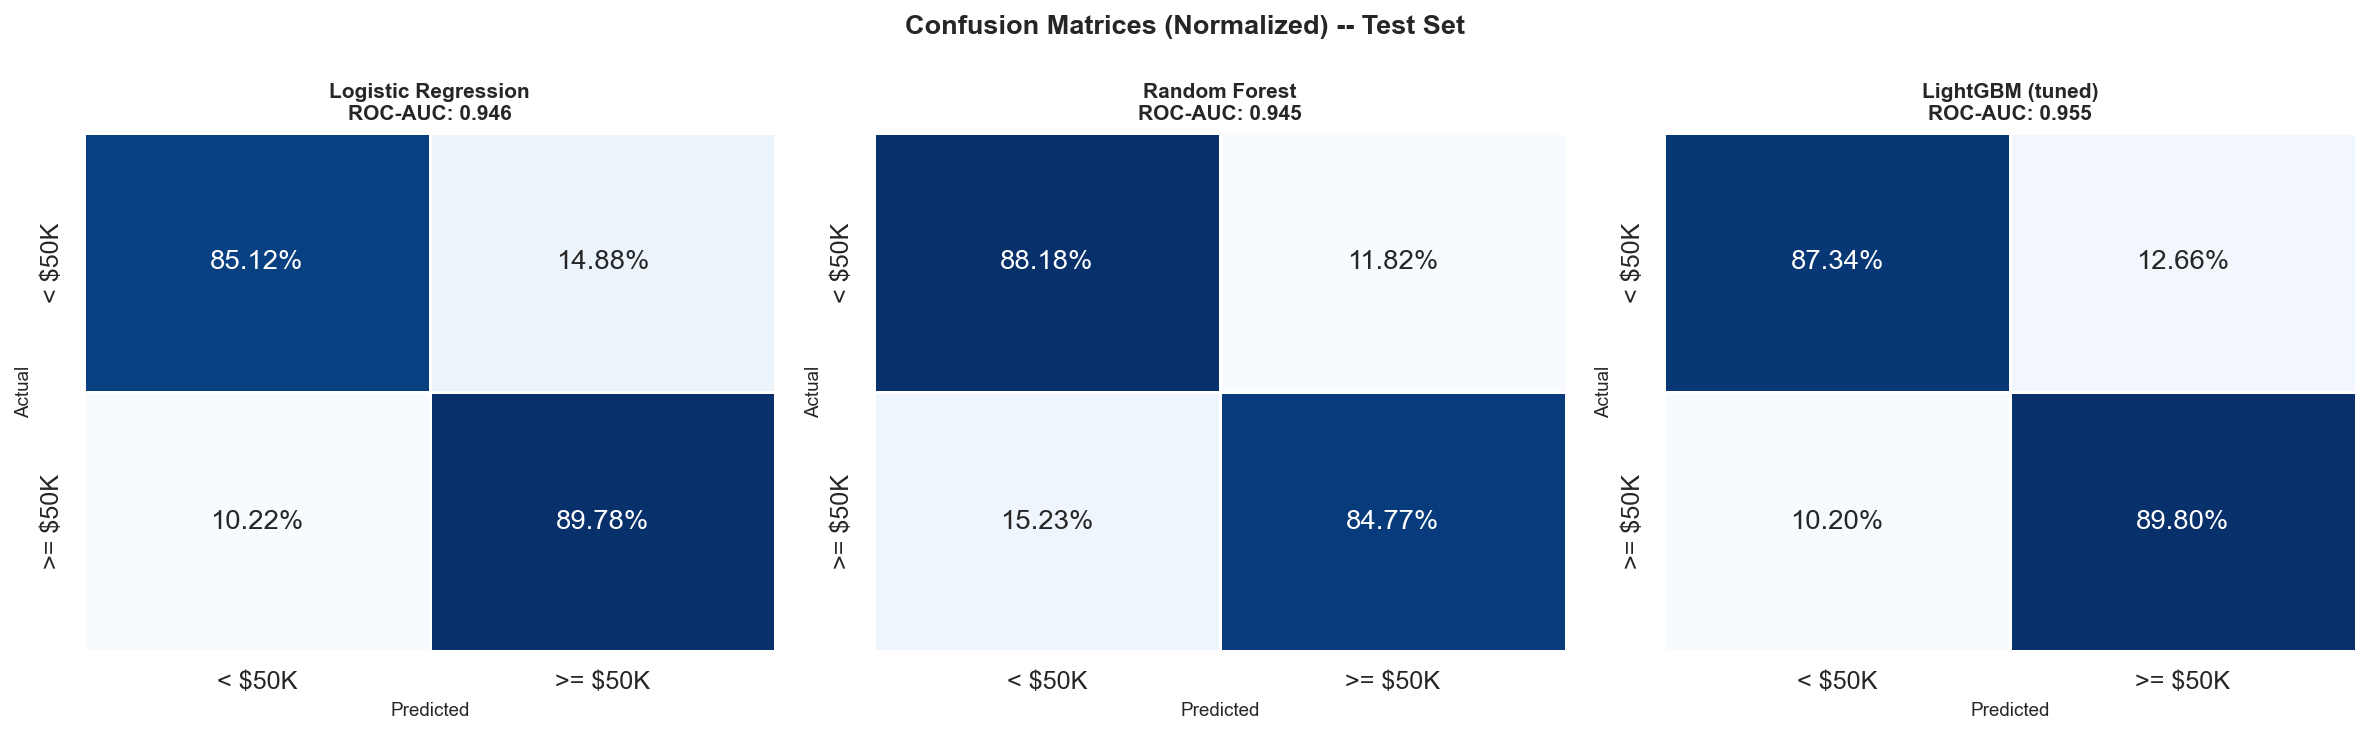

In [14]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, r) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, r['pred'], normalize='true')
    labels = [INCOME_LABELS[0], INCOME_LABELS[1]]
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nROC-AUC: {r["roc_auc"]:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

plt.suptitle('Confusion Matrices (Normalized) -- Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('20_confusion_matrices')

## 7. Threshold Analysis for LightGBM

The default 0.5 prediction threshold is rarely optimal for imbalanced problems. We sweep thresholds and plot precision, recall, and F1 to identify the best operating point for different use cases.

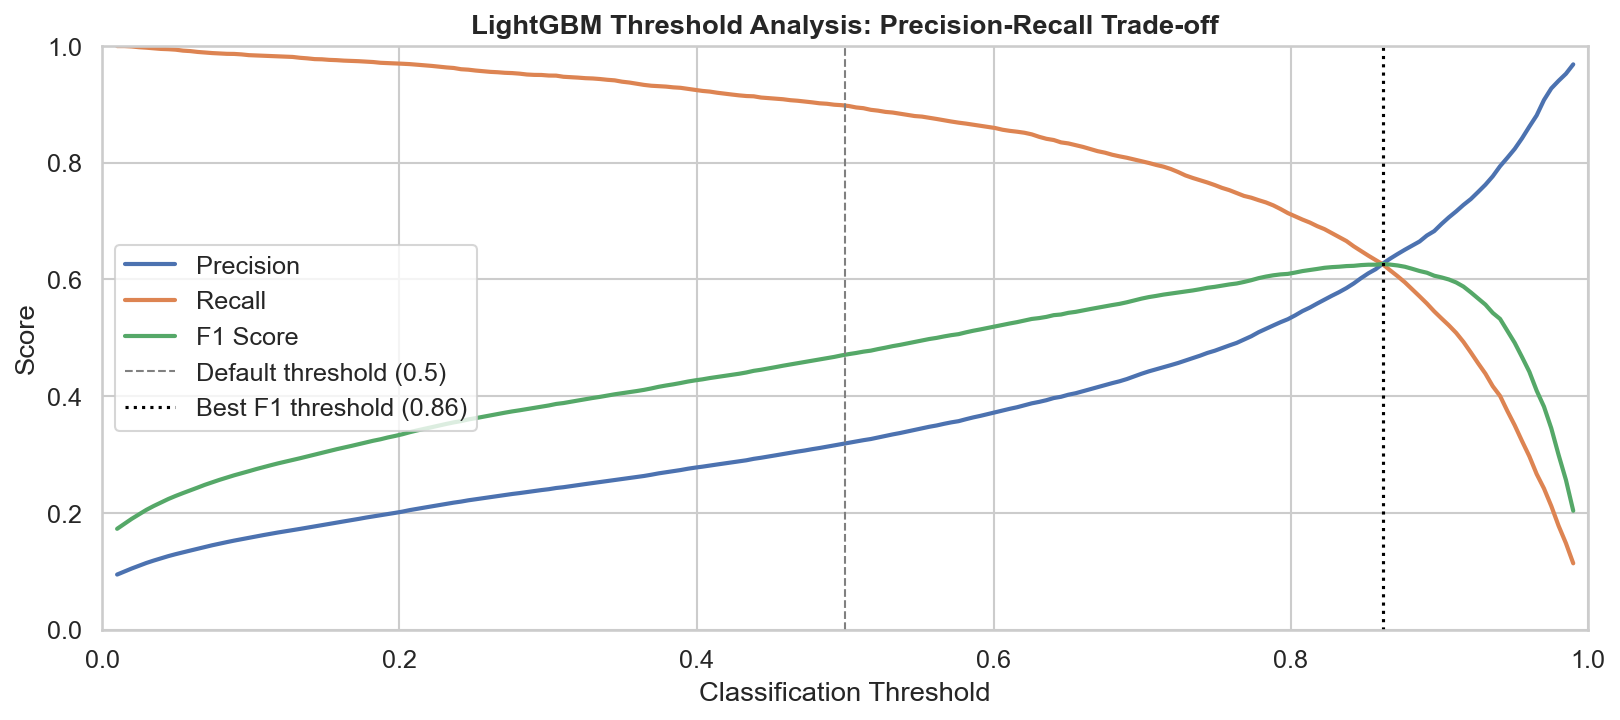

Best F1 threshold: 0.862
At this threshold: F1=0.627, Precision=0.627, Recall=0.626


In [15]:
lgbm_proba = test_results['LightGBM (tuned)']['proba']

thresholds = np.linspace(0.01, 0.99, 200)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    pred_t = (lgbm_proba >= t).astype(int)
    precisions.append(precision_score(y_test, pred_t, zero_division=0))
    recalls.append(recall_score(y_test, pred_t, zero_division=0))
    f1s.append(f1_score(y_test, pred_t, zero_division=0))

best_f1_idx = np.argmax(f1s)
best_threshold = thresholds[best_f1_idx]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, precisions, label='Precision', color='#4C72B0', linewidth=2)
ax.plot(thresholds, recalls, label='Recall', color='#DD8452', linewidth=2)
ax.plot(thresholds, f1s, label='F1 Score', color='#55A868', linewidth=2)
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Default threshold (0.5)')
ax.axvline(x=best_threshold, color='black', linestyle=':', linewidth=1.5,
           label=f'Best F1 threshold ({best_threshold:.2f})')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('LightGBM Threshold Analysis: Precision-Recall Trade-off', fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
savefig('21_threshold_analysis')

print(f'Best F1 threshold: {best_threshold:.3f}')
print(f'At this threshold: F1={f1s[best_f1_idx]:.3f}, '
      f'Precision={precisions[best_f1_idx]:.3f}, '
      f'Recall={recalls[best_f1_idx]:.3f}')

In [16]:
# Classification report at best F1 threshold
pred_best = (lgbm_proba >= best_threshold).astype(int)
print(f'Classification Report at threshold={best_threshold:.2f}:')
print(classification_report(
    y_test, pred_best,
    target_names=[INCOME_LABELS[0], INCOME_LABELS[1]]
))

Classification Report at threshold=0.86:
              precision    recall  f1-score   support

      < $50K       0.98      0.98      0.98     93576
     >= $50K       0.63      0.63      0.63      6186

    accuracy                           0.95     99762
   macro avg       0.80      0.80      0.80     99762
weighted avg       0.95      0.95      0.95     99762



## 8. Model Interpretability: SHAP

SHAP (SHapley Additive exPlanations) provides model-agnostic feature attributions grounded in game theory. Each prediction is decomposed into per-feature contributions that sum to the model output.

In [17]:
# Extract trained LightGBM model and preprocessed test data
lgbm_pipeline = test_results['LightGBM (tuned)']['pipeline']
lgbm_model = lgbm_pipeline.named_steps['clf']

# Sample for SHAP (full test set can be slow)
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_test_prep), size=min(5000, len(X_test_prep)), replace=False)
X_shap = X_test_prep[sample_idx]

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer(X_shap, check_additivity=False)

# Inject feature names so waterfall/beeswarm plots show readable labels instead of column indices
shap_values.feature_names = list(feature_names_out)

print(f'SHAP values computed for {X_shap.shape[0]} samples x {X_shap.shape[1]} features')

SHAP values computed for 5000 samples x 174 features


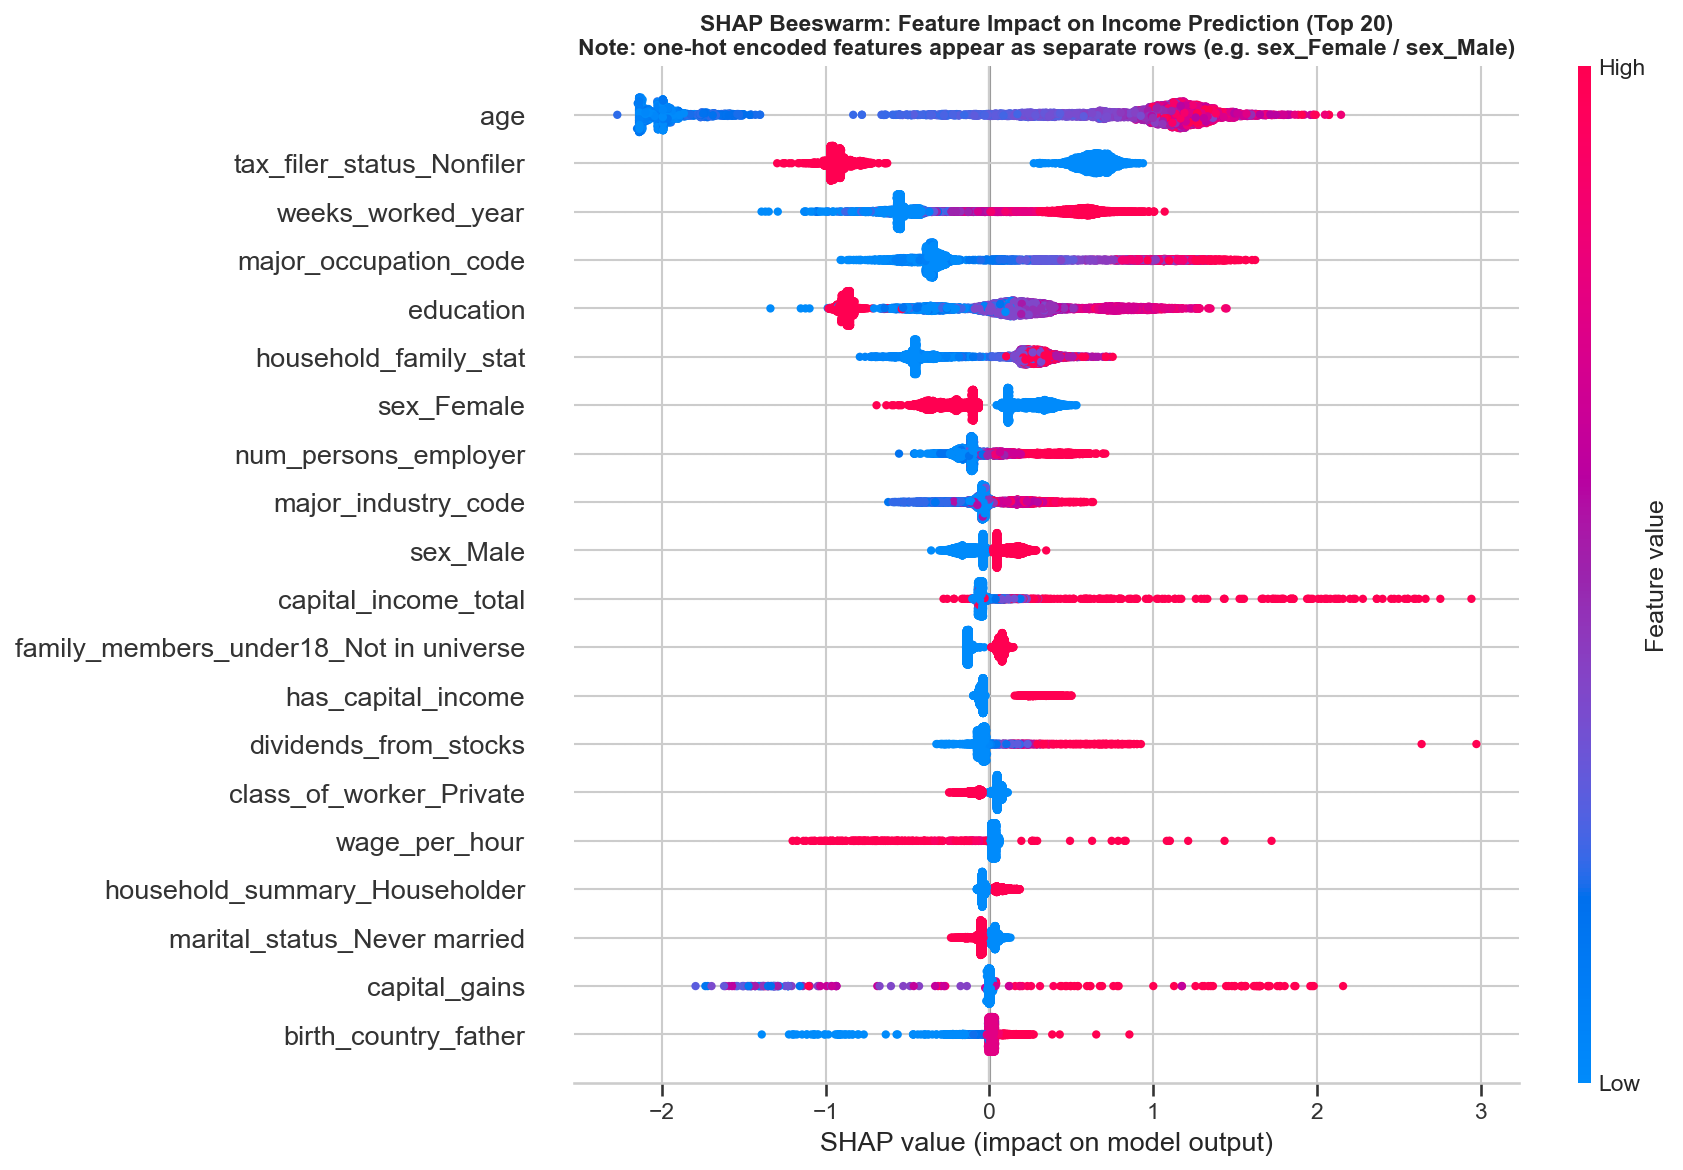

In [18]:
# SHAP Summary Plot (beeswarm)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=list(feature_names_out),
    max_display=20,
    show=False,
    plot_size=None,
)
plt.title('SHAP Beeswarm: Feature Impact on Income Prediction (Top 20)\n'
          'Note: one-hot encoded features appear as separate rows (e.g. sex_Female / sex_Male)',
          fontweight='bold', fontsize=11)
plt.tight_layout()
savefig('22_shap_beeswarm')

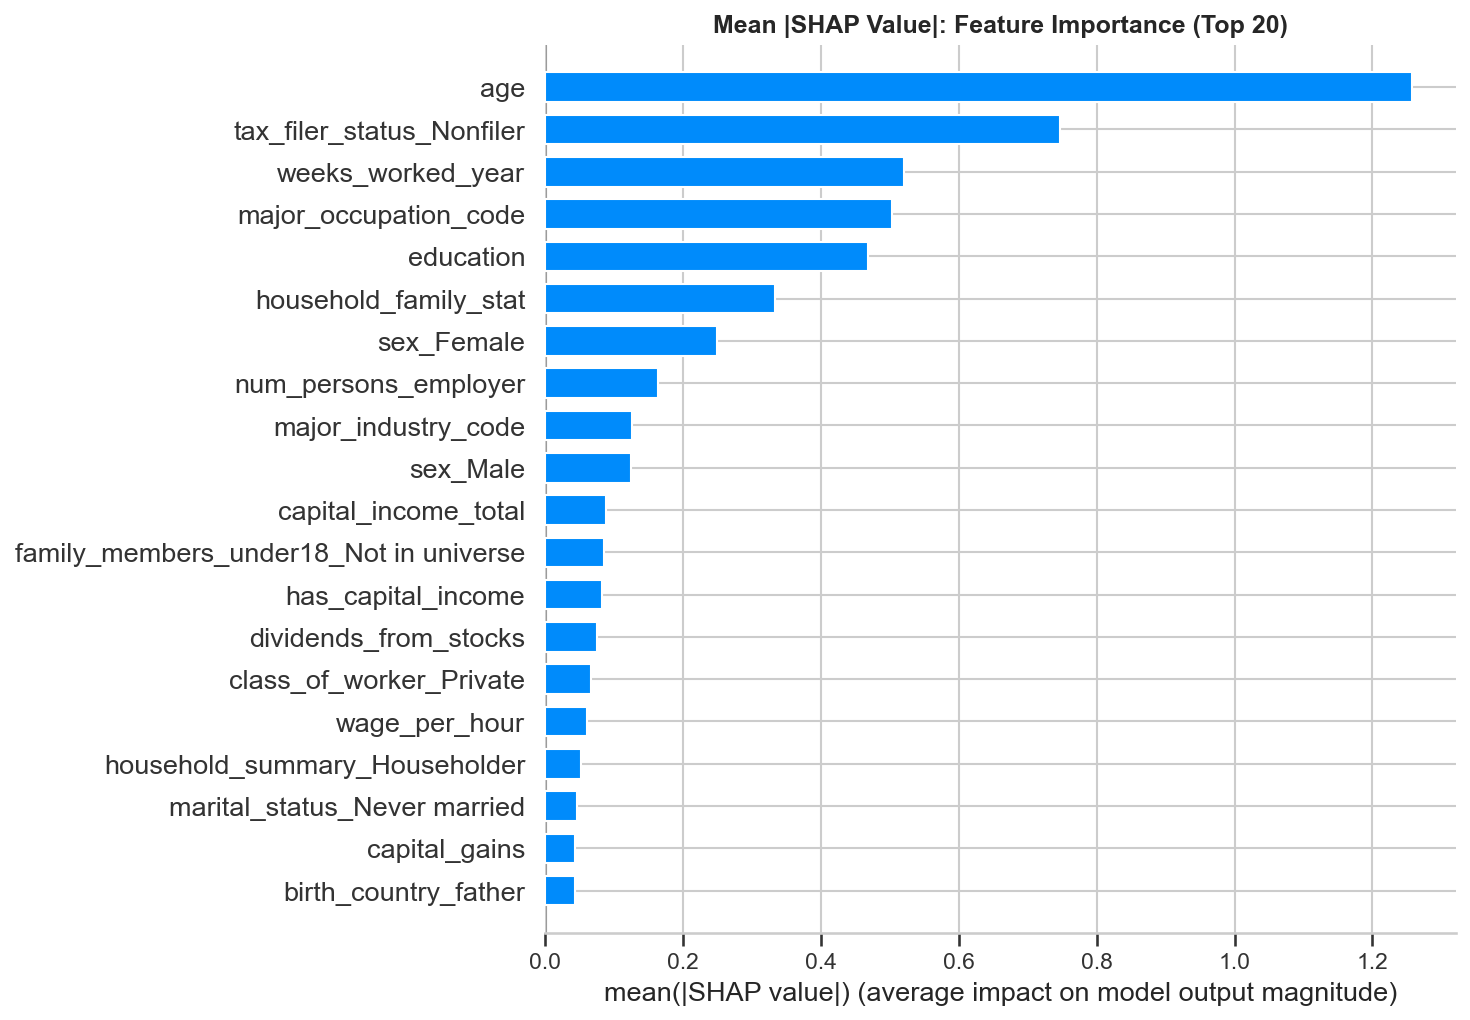

In [19]:
# SHAP Bar Plot: mean absolute importance
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=list(feature_names_out),
    plot_type='bar',
    max_display=20,
    show=False,
    plot_size=None,
)
plt.title('Mean |SHAP Value|: Feature Importance (Top 20)', fontweight='bold', fontsize=12)
plt.tight_layout()
savefig('23_shap_importance')

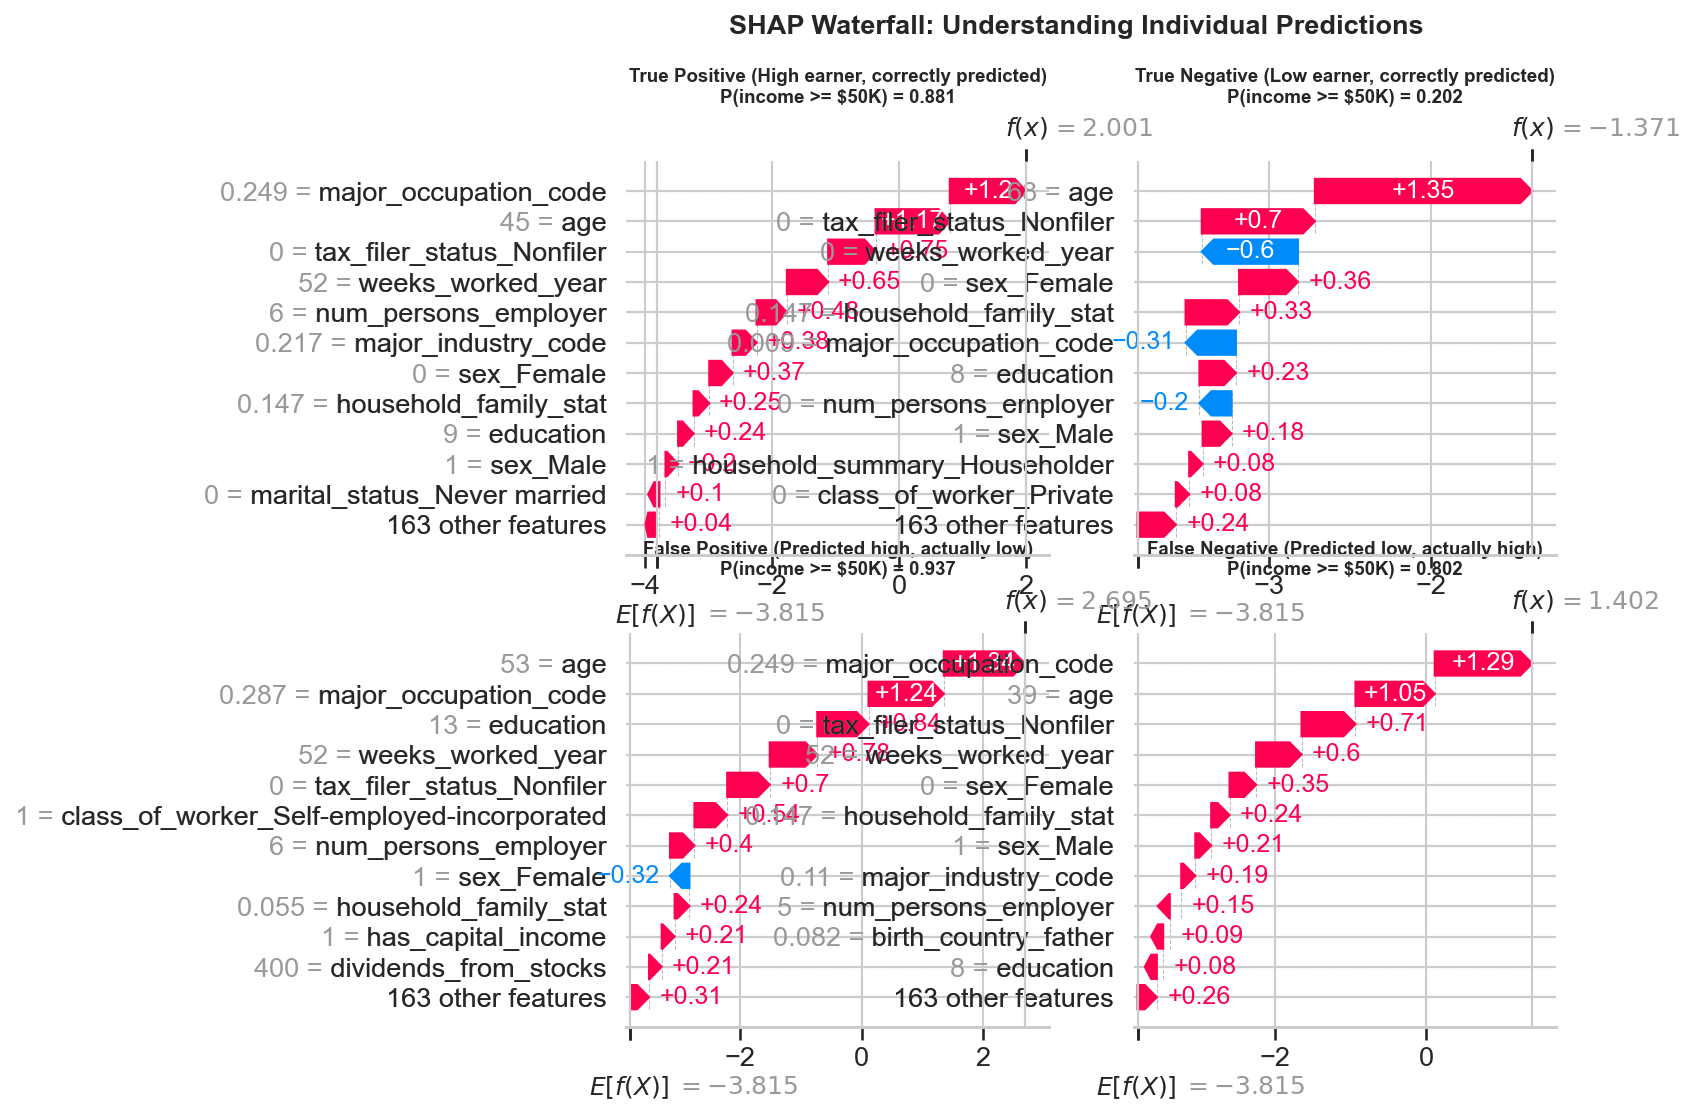

In [20]:
# SHAP Waterfall plots for representative individuals
y_test_sample = y_test.iloc[sample_idx].reset_index(drop=True)
proba_sample = lgbm_proba[sample_idx]

cases = {
    'True Positive (High earner, correctly predicted)': (
        np.where((y_test_sample == 1) & (proba_sample >= best_threshold))[0],
    ),
    'True Negative (Low earner, correctly predicted)': (
        np.where((y_test_sample == 0) & (proba_sample < best_threshold))[0],
    ),
    'False Positive (Predicted high, actually low)': (
        np.where((y_test_sample == 0) & (proba_sample >= best_threshold))[0],
    ),
    'False Negative (Predicted low, actually high)': (
        np.where((y_test_sample == 1) & (proba_sample < best_threshold))[0],
    ),
}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
for ax, (case_name, (candidates,)) in zip(axes.flatten(), cases.items()):
    if len(candidates) == 0:
        ax.text(0.5, 0.5, 'No examples found', ha='center', va='center')
        ax.set_title(case_name, fontweight='bold')
        continue
    idx = candidates[0]
    plt.sca(ax)
    # feature_names already set on shap_values object; waterfall reads them automatically
    shap.waterfall_plot(shap_values[idx], max_display=12, show=False)
    ax.set_title(f'{case_name}\nP(income >= $50K) = {proba_sample[idx]:.3f}',
                 fontweight='bold', fontsize=9)

plt.suptitle('SHAP Waterfall: Understanding Individual Predictions',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('24_shap_waterfall')

## 9. Save Model Artifacts and Results

In [21]:
# Save the full LightGBM pipeline (includes preprocessor)
joblib.dump(lgbm_pipeline, MODELS_DIR / 'lgbm_pipeline.joblib')
joblib.dump(prep, MODELS_DIR / 'preprocessor.joblib')

# Save preprocessed test data for fast SHAP reload
np.save(MODELS_DIR / 'X_test_prep.npy', X_test_prep)
np.save(MODELS_DIR / 'feature_names.npy', feature_names_out)

# Save evaluation metrics as JSON
metrics_out = {
    name: {
        k: float(v) for k, v in r.items() if k not in ['pipeline', 'proba', 'pred']
    }
    for name, r in test_results.items()
}
metrics_out['best_threshold'] = float(best_threshold)
metrics_out['cv_roc_auc'] = {
    name: {'mean': float(scores.mean()), 'std': float(scores.std())}
    for name, scores in cv_results.items()
}
metrics_out['best_lgbm_params'] = {k: (float(v) if isinstance(v, (int, float)) else v)
                                    for k, v in best_params.items()}

(MODELS_DIR / 'metrics.json').write_text(json.dumps(metrics_out, indent=2))
print('Model artifacts and metrics saved.')

Model artifacts and metrics saved.


In [23]:
# Write modeling decisions doc
lgbm_result = test_results['LightGBM (tuned)']
lr_result   = test_results['Logistic Regression']
rf_result   = test_results['Random Forest']

modeling_doc = f"""
# Modeling Decisions

## Feature Engineering Rationale

- **Dropped detailed_industry/occupation_recode:** These are finer-grained recodes of the major_industry_code
  and major_occupation_code columns. Retaining both inflates dimensionality without proportional gain.
  The major codes capture the primary signal.

- **has_capital_income (binary flag):** Capital gains and dividends are zero for 96%+ of records but
  carry strong discriminative power. A binary flag captures group membership without being overwhelmed
  by the skewed magnitude distribution.

- **Education as ordinal:** The EDA confirmed a near-monotonic income increase with education level.
  Ordinal encoding preserves this ordering signal. One-hot encoding would break the monotonicity assumption.

- **Migration columns:** High structural missingness (~65%) because non-movers have no migration data.
  NaN filled with 'Missing' category (treated as a dedicated 'Non-mover' group).

- **Target encoding for high-cardinality categoricals:** State, country of birth, and household family
  stat have 40-50 unique values. One-hot encoding would create hundreds of sparse columns. Target
  encoding with cross-fold smoothing (sklearn TargetEncoder) prevents overfitting and reduces
  dimensionality while capturing the signal.

## Model Selection Rationale

- **LightGBM selected as final model** (ROC-AUC: {lgbm_result['roc_auc']:.4f}) over:
  - Random Forest  (ROC-AUC: {rf_result['roc_auc']:.4f})
  - Logistic Regression (ROC-AUC: {lr_result['roc_auc']:.4f})

- LightGBM advantages: native NaN handling, faster training than RF, superior handling of mixed
  feature types, built-in class imbalance correction via scale_pos_weight.

## Class Imbalance Strategy

- Used scale_pos_weight = {scale_pos_weight:.1f} (negative/positive ratio) in LightGBM.
- Chose scale_pos_weight over SMOTE: SMOTE generates synthetic samples that may not reflect the
  true data-generating process; instance weights already account for sampling in this dataset.
- Threshold tuned to {best_threshold:.2f} (optimal F1) vs default 0.5.

## Evaluation Metric Choice

- **Primary: ROC-AUC** -- threshold-independent, robust to class imbalance
- **Secondary: PR-AUC** -- directly measures performance on the minority (positive) class;
  more informative than ROC-AUC for highly imbalanced problems
- **Accuracy deliberately avoided** -- 93.8% trivially achievable by predicting all-negative

## Limitations

- Data spans 1994-1995; income patterns have shifted substantially (inflation, wage growth, tax law).
- No causal inference: feature importance shows association, not causation.
- Conflicting instances (same features, different labels) suggest labeling noise or true ambiguity.
- Production deployment would require monitoring for demographic drift.
"""

(DOCS_DIR / 'modeling_decisions.md').write_text(modeling_doc)
print('Modeling decisions saved.')
print('\n=== MODELING COMPLETE ===')
print(f'Final LightGBM ROC-AUC: {lgbm_result["roc_auc"]:.4f}')
print(f'Final LightGBM PR-AUC:  {lgbm_result["pr_auc"]:.4f}')
print(f'Best F1 threshold: {best_threshold:.3f}')

Modeling decisions saved.

=== MODELING COMPLETE ===
Final LightGBM ROC-AUC: 0.9554
Final LightGBM PR-AUC:  0.6805
Best F1 threshold: 0.862
